# Cluster stats

The purpose of this notebook is to analyze `STATE x leiden cluster` matrices for each accession.

## Data preparation

The data were produced by [`pipelines/cluster_stats.py`](../pipelines/cluster_stats.py) in run [`cluster_stats/clustered_20260509`](../output/cluster_stats/clustered_20260509). All aformentioned matrices were written to [`cluster_stats.json`](../output/cluster_stats/clustered_20260509/cluster_stats.json)

## Imports

In [1]:
from shared.repo import REPO_ROOT
from pathlib import Path
import json
import numpy as np
import pandas as pd
import xarray as xr
from scipy import stats
import matplotlib.pyplot as plt

## Construct `xarray.DataArray` object

In [2]:
CLUSTER_STATS_PATH = (
    REPO_ROOT / "output/cluster_stats/clustered_20260509/cluster_stats.json"
)

with open(CLUSTER_STATS_PATH) as f:
    _data = json.load(f)

samples    = list(_data.keys())
cell_types = sorted({ct for s in _data.values() for ct in s.keys()})
clusters   = sorted(
    {cl for s in _data.values() for ct in s.values() for cl in ct.keys()},
    key=int,
)

arr = np.zeros((len(samples), len(cell_types), len(clusters)), dtype=np.int32)

for i, sample in enumerate(samples):
    for j, cell_type in enumerate(cell_types):
        for k, cluster in enumerate(clusters):
            arr[i, j, k] = _data[sample].get(cell_type, {}).get(cluster, 0)

da = xr.DataArray(
    arr,
    dims=["accession", "STATE", "leiden_cluster"],
    coords={"accession": samples, "STATE": cell_types, "leiden_cluster": clusters},
    name="cell_count",
)

# da

## Stats
### Compute metrics across leiden clusters
- Shannon entropy
- Normalized Shannon entropy = `Shannon entropy / log(n_states)`

In [3]:
import numpy as np
from scipy.stats import entropy

entropy_bits = np.full((da.sizes["accession"], da.sizes["leiden_cluster"]), np.nan, dtype=float)
nse_per_cluster = np.full_like(entropy_bits, np.nan)
# nse_arr = np.zeros((da.sizes["accession"], 2), dtype=np.float32)
nse_arr = []

for i, a in enumerate(da.accession.values):
    # Get the counts for the current accession
    sub = da.sel(accession=a).values
    for j in range(sub.shape[1]):
        # Probability distribution of STATE in current cluster
        pk = sub[:, j]
        # Skip clusters IDs with no cells
        if pk.sum() == 0:
            continue
        # Number of STATES in cluster
        k = len(pk[pk > 0])
        # Shannon entropy of STATE distribution in cluster
        h = stats.entropy(pk, base=2)
        entropy_bits[i, j] = h
        # Normalized Shannon entropy of STATE distribution in cluster
        nse_per_cluster[i, j] = h / np.log2(k) if k > 1 else 0.0
        nse_arr.append([nse_per_cluster[i, j], pk.sum()])

coords = {"accession": da.accession, "leiden_cluster": da.leiden_cluster}
da_entropy = xr.DataArray(
    entropy_bits,
    dims=("accession", "leiden_cluster"),
    coords=coords,
    name="state_entropy_bits",
)
da_entropy_nse = xr.DataArray(
    nse_per_cluster,
    dims=("accession", "leiden_cluster"),
    coords=coords,
    name="state_mixing_nse",
)

arr = np.asarray(nse_arr, dtype=float)
nse_vals = arr[:, 0]
sizes = np.maximum(arr[:, 1].astype(np.float64), 1.0)
log_sz = np.log2(sizes)

# da_entropy

### Confirm that the distribution of leiden cluster sizes is lognormal

lognormal fit:  mu = 5.564,  sigma = 1.228  (loc fixed at 0)
KS test vs fitted lognormal:  D = 0.0241,  p = 6.6e-05


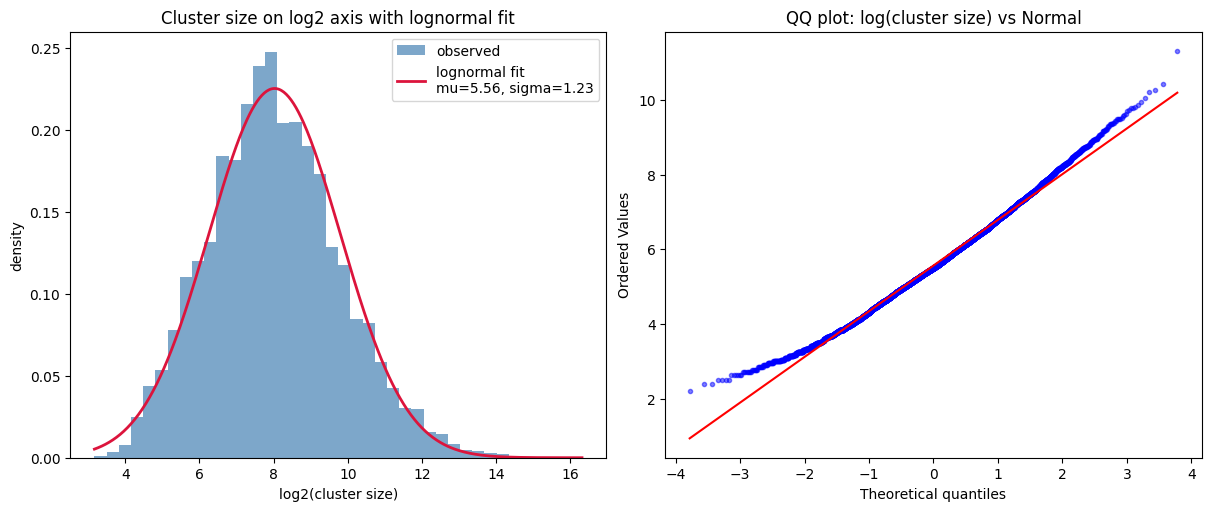

In [4]:
shape, loc, scale = stats.lognorm.fit(sizes, floc=0)
mu, sigma = np.log(scale), shape
print(f"lognormal fit:  mu = {mu:.3f},  sigma = {sigma:.3f}  (loc fixed at 0)")

ks_stat, ks_p = stats.kstest(sizes, "lognorm", args=(shape, loc, scale))
print(f"KS test vs fitted lognormal:  D = {ks_stat:.4f},  p = {ks_p:.3g}")

fig, (ax_hist, ax_qq) = plt.subplots(1, 2, figsize=(12, 5), layout="constrained")

ax_hist.hist(log_sz, bins=40, density=True, color="steelblue", alpha=0.7, label="observed")
xx = np.linspace(log_sz.min(), log_sz.max(), 400)
pdf_log = stats.norm.pdf(xx, loc=mu / np.log(2), scale=sigma / np.log(2))
ax_hist.plot(xx, pdf_log, color="crimson", lw=2, label=f"lognormal fit\nmu={mu:.2f}, sigma={sigma:.2f}")
ax_hist.set_xlabel("log2(cluster size)")
ax_hist.set_ylabel("density")
ax_hist.set_title("Cluster size on log2 axis with lognormal fit")
ax_hist.legend()

stats.probplot(np.log(sizes), dist="norm", plot=ax_qq)
ax_qq.set_title("QQ plot: log(cluster size) vs Normal")
ax_qq.get_lines()[0].set_markersize(3)
ax_qq.get_lines()[0].set_alpha(0.5)

plt.show()

## Plotting

### Distribution of entropy of leiden clusters across cluster size bins

one-way ANOVA: F = 86.9330,  p = 1.956e-55


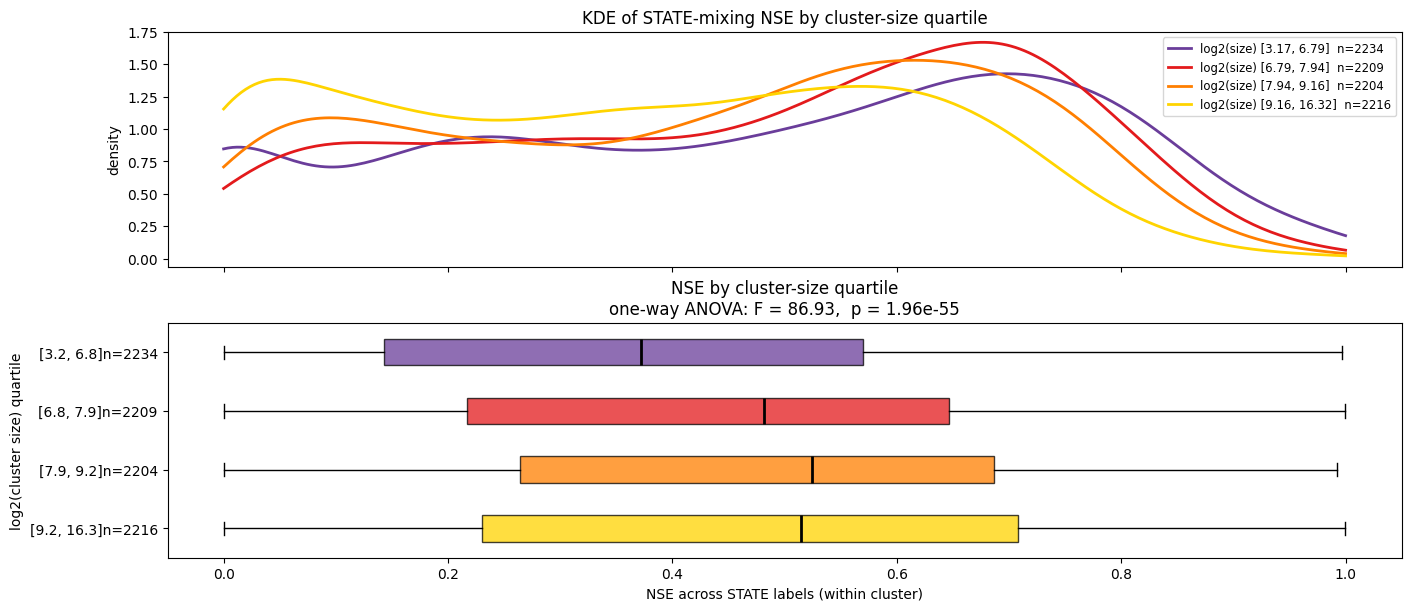

In [ ]:
bins = pd.qcut(log_sz, q=4, duplicates="drop")
fig, axes = plt.subplots(2, 1, figsize=(14, 6), layout="constrained", sharex=True)

n_cats = len(bins.categories)
if n_cats == 4:
    palette = ["#6a3d9a", "#e31a1c", "#ff7f00", "#ffd400"]
else:
    palette = [plt.cm.plasma(t) for t in np.linspace(0.1, 0.9, max(n_cats, 1))]

bin_codes = np.asarray(bins.codes)
groups = []
labels = []
for idx, interval in enumerate(bins.categories):
    mask = bin_codes == idx
    sub = nse_vals[mask]
    sub = sub[np.isfinite(sub)]
    groups.append(sub)
    labels.append(f"[{interval.left:.1f}, {interval.right:.1f}]n={mask.sum():d}")

# KDE plot
axx = axes[0]
for idx, (sub, interval) in enumerate(zip(groups, bins.categories)):
    if sub.size < 2:
        continue
    kde = stats.gaussian_kde(sub)
    pad = max((sub.max() - sub.min()) * 0.08, 0.02)
    lo, hi = max(0.0, sub.min() - pad), min(1.0, sub.max() + pad)
    xx = np.linspace(lo, hi, 256)
    axx.plot(xx, kde(xx), color=palette[idx], lw=2,
             label=f"log2(size) [{interval.left:.2f}, {interval.right:.2f}]  n={sub.size:d}")
axx.set_title("KDE of STATE-mixing NSE by cluster-size quartile")
# axx.set_xlabel("NSE across STATE labels (within cluster)")
axx.set_ylabel("density")
axx.legend(loc="best", fontsize="small")

# Boxplot
axb = axes[1]
bp = axb.boxplot(
    groups,
    tick_labels=labels,
    orientation="horizontal",
    patch_artist=True,
    medianprops=dict(color="black", lw=2),
    flierprops=dict(marker="o", markersize=2, alpha=0.3),
)
for patch, color in zip(bp["boxes"], palette[::-1]):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

f_stat, p_anova = stats.f_oneway(*groups)
axb.set_title(
    f"NSE by cluster-size quartile\n"
    f"one-way ANOVA: F = {f_stat:.2f},  p = {p_anova:.2e}"
)
axb.set_ylabel("log2(cluster size) quartile")
axb.set_xlabel("NSE across STATE labels (within cluster)")

print(f"one-way ANOVA: F = {f_stat:.4f},  p = {p_anova:.3e}")
plt.show()

# TODO: boxplot is backwards